In [34]:
import pandas as pd              # data loading and manipulation
import numpy as np               # numerical operations for the IDM simulation
import matplotlib.pyplot as plt  # core plotting library
import seaborn as sns            # statistical visualizations built on matplotlib

sns.set_style('whitegrid')  # clean white grid background for all plots
sns.set_palette('deep')     # default color palette for seaborn plots

In [35]:
ngsim = pd.read_csv('NGSIM.csv')      # load NGSIM vehicle trajectory dataset
traveldata = pd.read_csv('NHTS.csv')  # load NHTS household travel survey dataset

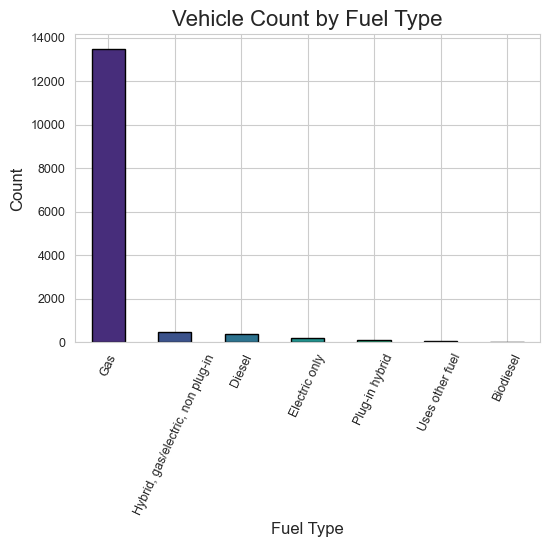

In [36]:
fuelcounts = traveldata['fuel_type'].value_counts().dropna()  # count vehicles by fuel type, drop missing values

plt.figure(figsize=(6, 4))
fuelcounts.plot(kind='bar', edgecolor='black', color=sns.color_palette('viridis', len(fuelcounts)))  # bar chart with viridis color gradient
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Vehicle Count by Fuel Type', fontsize=16)
plt.xticks(fontsize=9, rotation=65)  # rotate labels to prevent overlap
plt.yticks(fontsize=9)
plt.show()

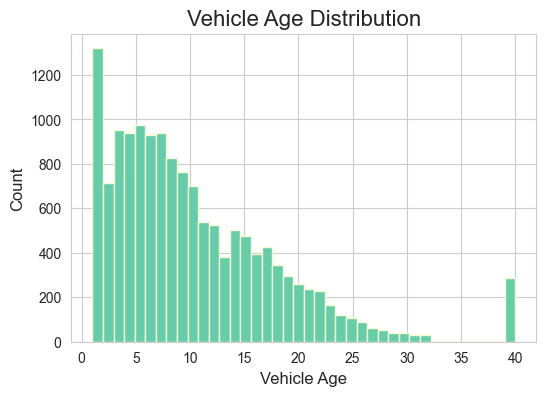

In [37]:
plt.figure(figsize=(6, 4))
plt.hist(traveldata['vehicle_age'], bins=40, color='mediumaquamarine', edgecolor='lightgoldenrodyellow')  # 40-bin histogram with custom colors
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Vehicle Age Distribution', fontsize=16)
plt.show()

<Figure size 1600x1000 with 0 Axes>

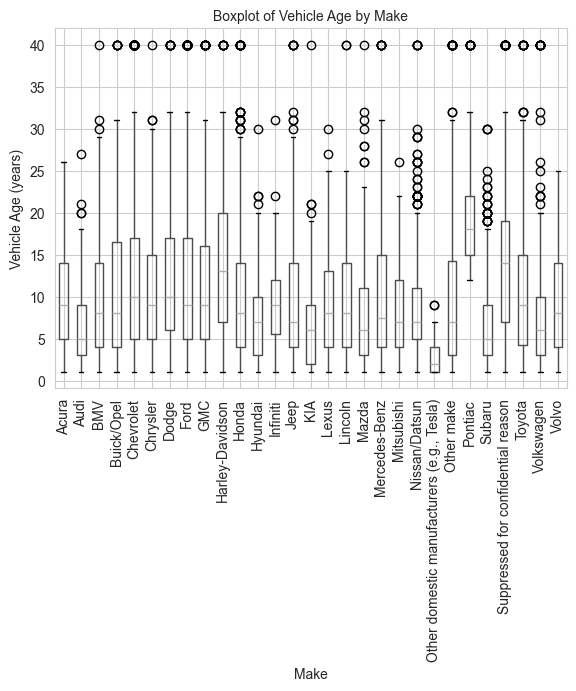

In [38]:
plt.figure(figsize=(16, 10))
boxplot = traveldata.boxplot(column='vehicle_age', by='make')  # vehicle age distribution grouped by make
plt.xticks(rotation=90)  # rotate make names so they do not overlap
plt.xlabel('Make', fontsize=10)
plt.ylabel('Vehicle Age (years)', fontsize=10)
plt.title('Boxplot of Vehicle Age by Make', fontsize=10)
plt.suptitle('')  # remove the automatic pandas subtitle
plt.show()

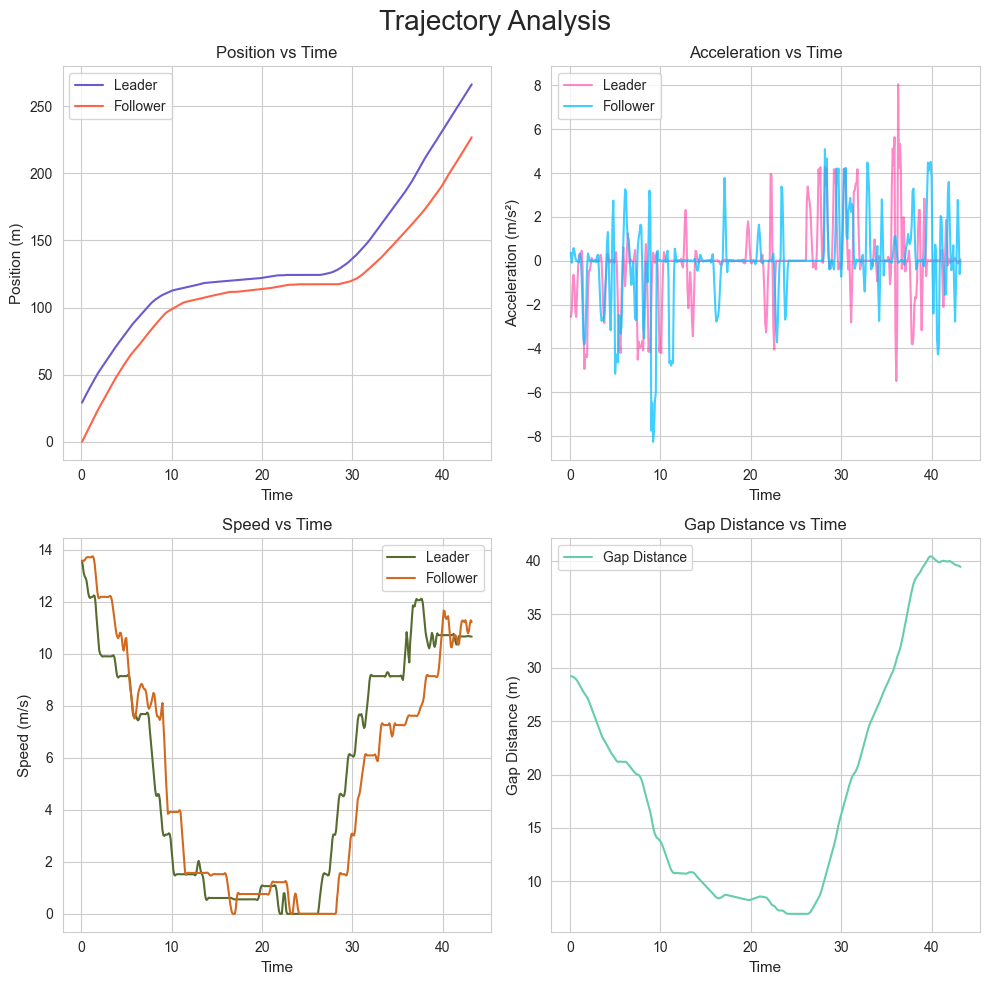

In [41]:
trajectorynumber = 10
data_subset = ngsim[ngsim['trajectory_number'] == trajectorynumber]  # filter to chosen vehicle pair
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values  # derive gap distance
time = data_subset['Time'].values

fig, axes = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid of subplots

# Position vs Time
axes[0,0].plot(time, data_subset['leader_position(m)'].values, linewidth=1.5, label='Leader', color='slateblue')
axes[0,0].plot(time, data_subset['follower_position(m)'].values, linewidth=1.5, label='Follower', color='tomato')
axes[0,0].set_ylabel('Position (m)', fontsize=11)
axes[0,0].set_xlabel('Time', fontsize=11)
axes[0,0].set_title('Position vs Time', fontsize=12)
axes[0,0].legend(fontsize=10)

# Speed vs Time
axes[1,0].plot(time, data_subset['leader_speed(m/s)'].values, linewidth=1.5, label='Leader', color='darkolivegreen')
axes[1,0].plot(time, data_subset['follower_speed(m/s)'].values, linewidth=1.5, label='Follower', color='chocolate')
axes[1,0].set_ylabel('Speed (m/s)', fontsize=11)
axes[1,0].set_xlabel('Time', fontsize=11)
axes[1,0].set_title('Speed vs Time', fontsize=12)
axes[1,0].legend(fontsize=10)

# Acceleration vs Time
axes[0,1].plot(time, data_subset['leader_acc(m/s^2)'].values, linewidth=1.5, label='Leader', color='deeppink', alpha=0.5)
axes[0,1].plot(time, data_subset['follower_acc(m/s^2)'].values, linewidth=1.5, label='Follower', color='deepskyblue', alpha=0.75)
axes[0,1].set_ylabel('Acceleration (m/s²)', fontsize=11)
axes[0,1].set_xlabel('Time', fontsize=11)
axes[0,1].set_title('Acceleration vs Time', fontsize=12)
axes[0,1].legend(fontsize=10)

# Gap Distance vs Time
axes[1,1].plot(time, gap, linewidth=1.5, label='Gap Distance', color='mediumaquamarine')
axes[1,1].set_ylabel('Gap Distance (m)', fontsize=11)
axes[1,1].set_xlabel('Time', fontsize=11)
axes[1,1].set_title('Gap Distance vs Time', fontsize=12)
axes[1,1].legend(fontsize=10)

fig.suptitle('Trajectory Analysis', fontsize=20)
plt.tight_layout()  # adjust spacing so subplot titles and labels do not overlap
plt.show()

In [23]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    return acceleration

In [24]:
datasubset = ngsim[ngsim['trajectory_number'] == trajectorynumber].reset_index(drop = True)
# Extract the leader's position and speed over time
timedata = datasubset['Time'].values
leaderposition = datasubset['leader_position(m)'].values
leaderspeed = datasubset['leader_speed(m/s)'].values
# Identifying the time step in our data
dt = 0.1    #seconds

In [31]:
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
nsteps = len(timedata)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
simposition = np.zeros(nsteps)         # simulated follower position; we will create a vector with all zeroes  as a start
simspeed = np.zeros(nsteps)         # simulated follower speed; we will create a vector with all zeroes  as a start
simacc = np.zeros(nsteps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
simposition[0] = datasubset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
simspeed[0] = datasubset['follower_speed(m/s)'].values[0]        #this makes the starting value [0] same as the follower vehicle speed

In [32]:
for i in range(nsteps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leaderposition[i] - simposition[i], .1)
    delta_v = simspeed[i] - leaderspeed[i]

    # Step 3: Use the IDM function to calculate acceleration
    simacc[i] = idm_acceleration(simspeed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    simspeed[i+1] = max(simspeed[i] + simacc[i]*dt, 0)
    simposition[i+1] = simposition[i] + simspeed[i]*dt

print("Simulation complete!")

Simulation complete!


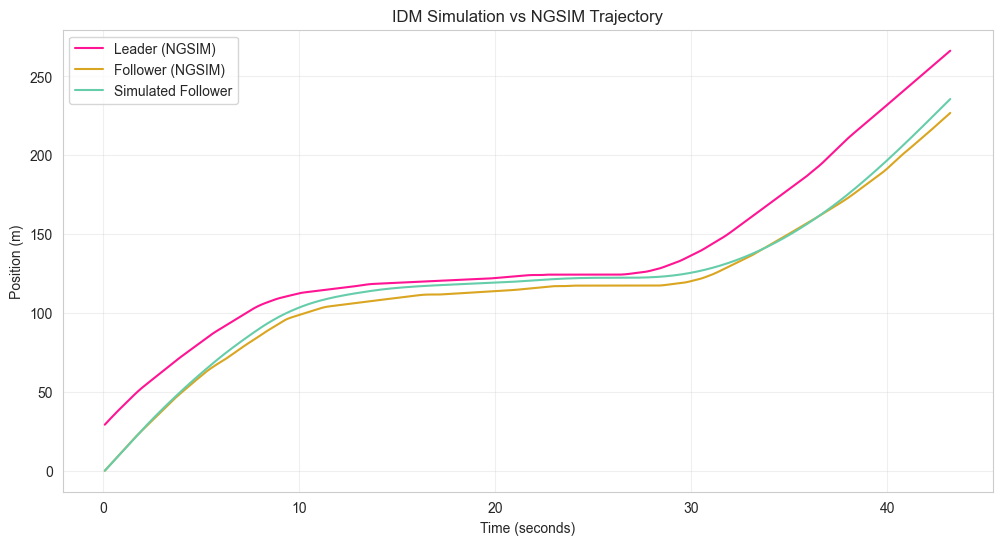

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(timedata, leaderposition, label='Leader (NGSIM)', color='deeppink')                        # real leader trajectory
plt.plot(timedata, datasubset['follower_position(m)'].values, label='Follower (NGSIM)', color='goldenrod')  # real follower trajectory
plt.plot(timedata, simposition, label='Simulated Follower', color='mediumaquamarine')               # IDM-simulated follower trajectory
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('IDM Simulation vs NGSIM Trajectory') 
plt.legend()
plt.grid(True, alpha=0.3)  # light grid for readability
plt.show()